#### Columns

>* age
>* sex
>* chest pain type (4 values)
>* resting blood pressure
>* serum cholestoral in mg/dl
>* fasting blood sugar > 120 mg/dl
>* resting electrocardiographic results (values 0,1,2)
>* maximum heart rate achieved
>* exercise induced angina
>* oldpeak = ST depression induced by exercise relative to rest
>* the slope of the peak exercise ST segment

In [293]:
import pandas as pd

In [294]:
df = pd.read_csv("../data/raw/heart.csv")

In [295]:
df.columns 

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [296]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


> The goal is to predict wether the patient has a **heart disease** or not, based on the variables avaliable in this dataset.

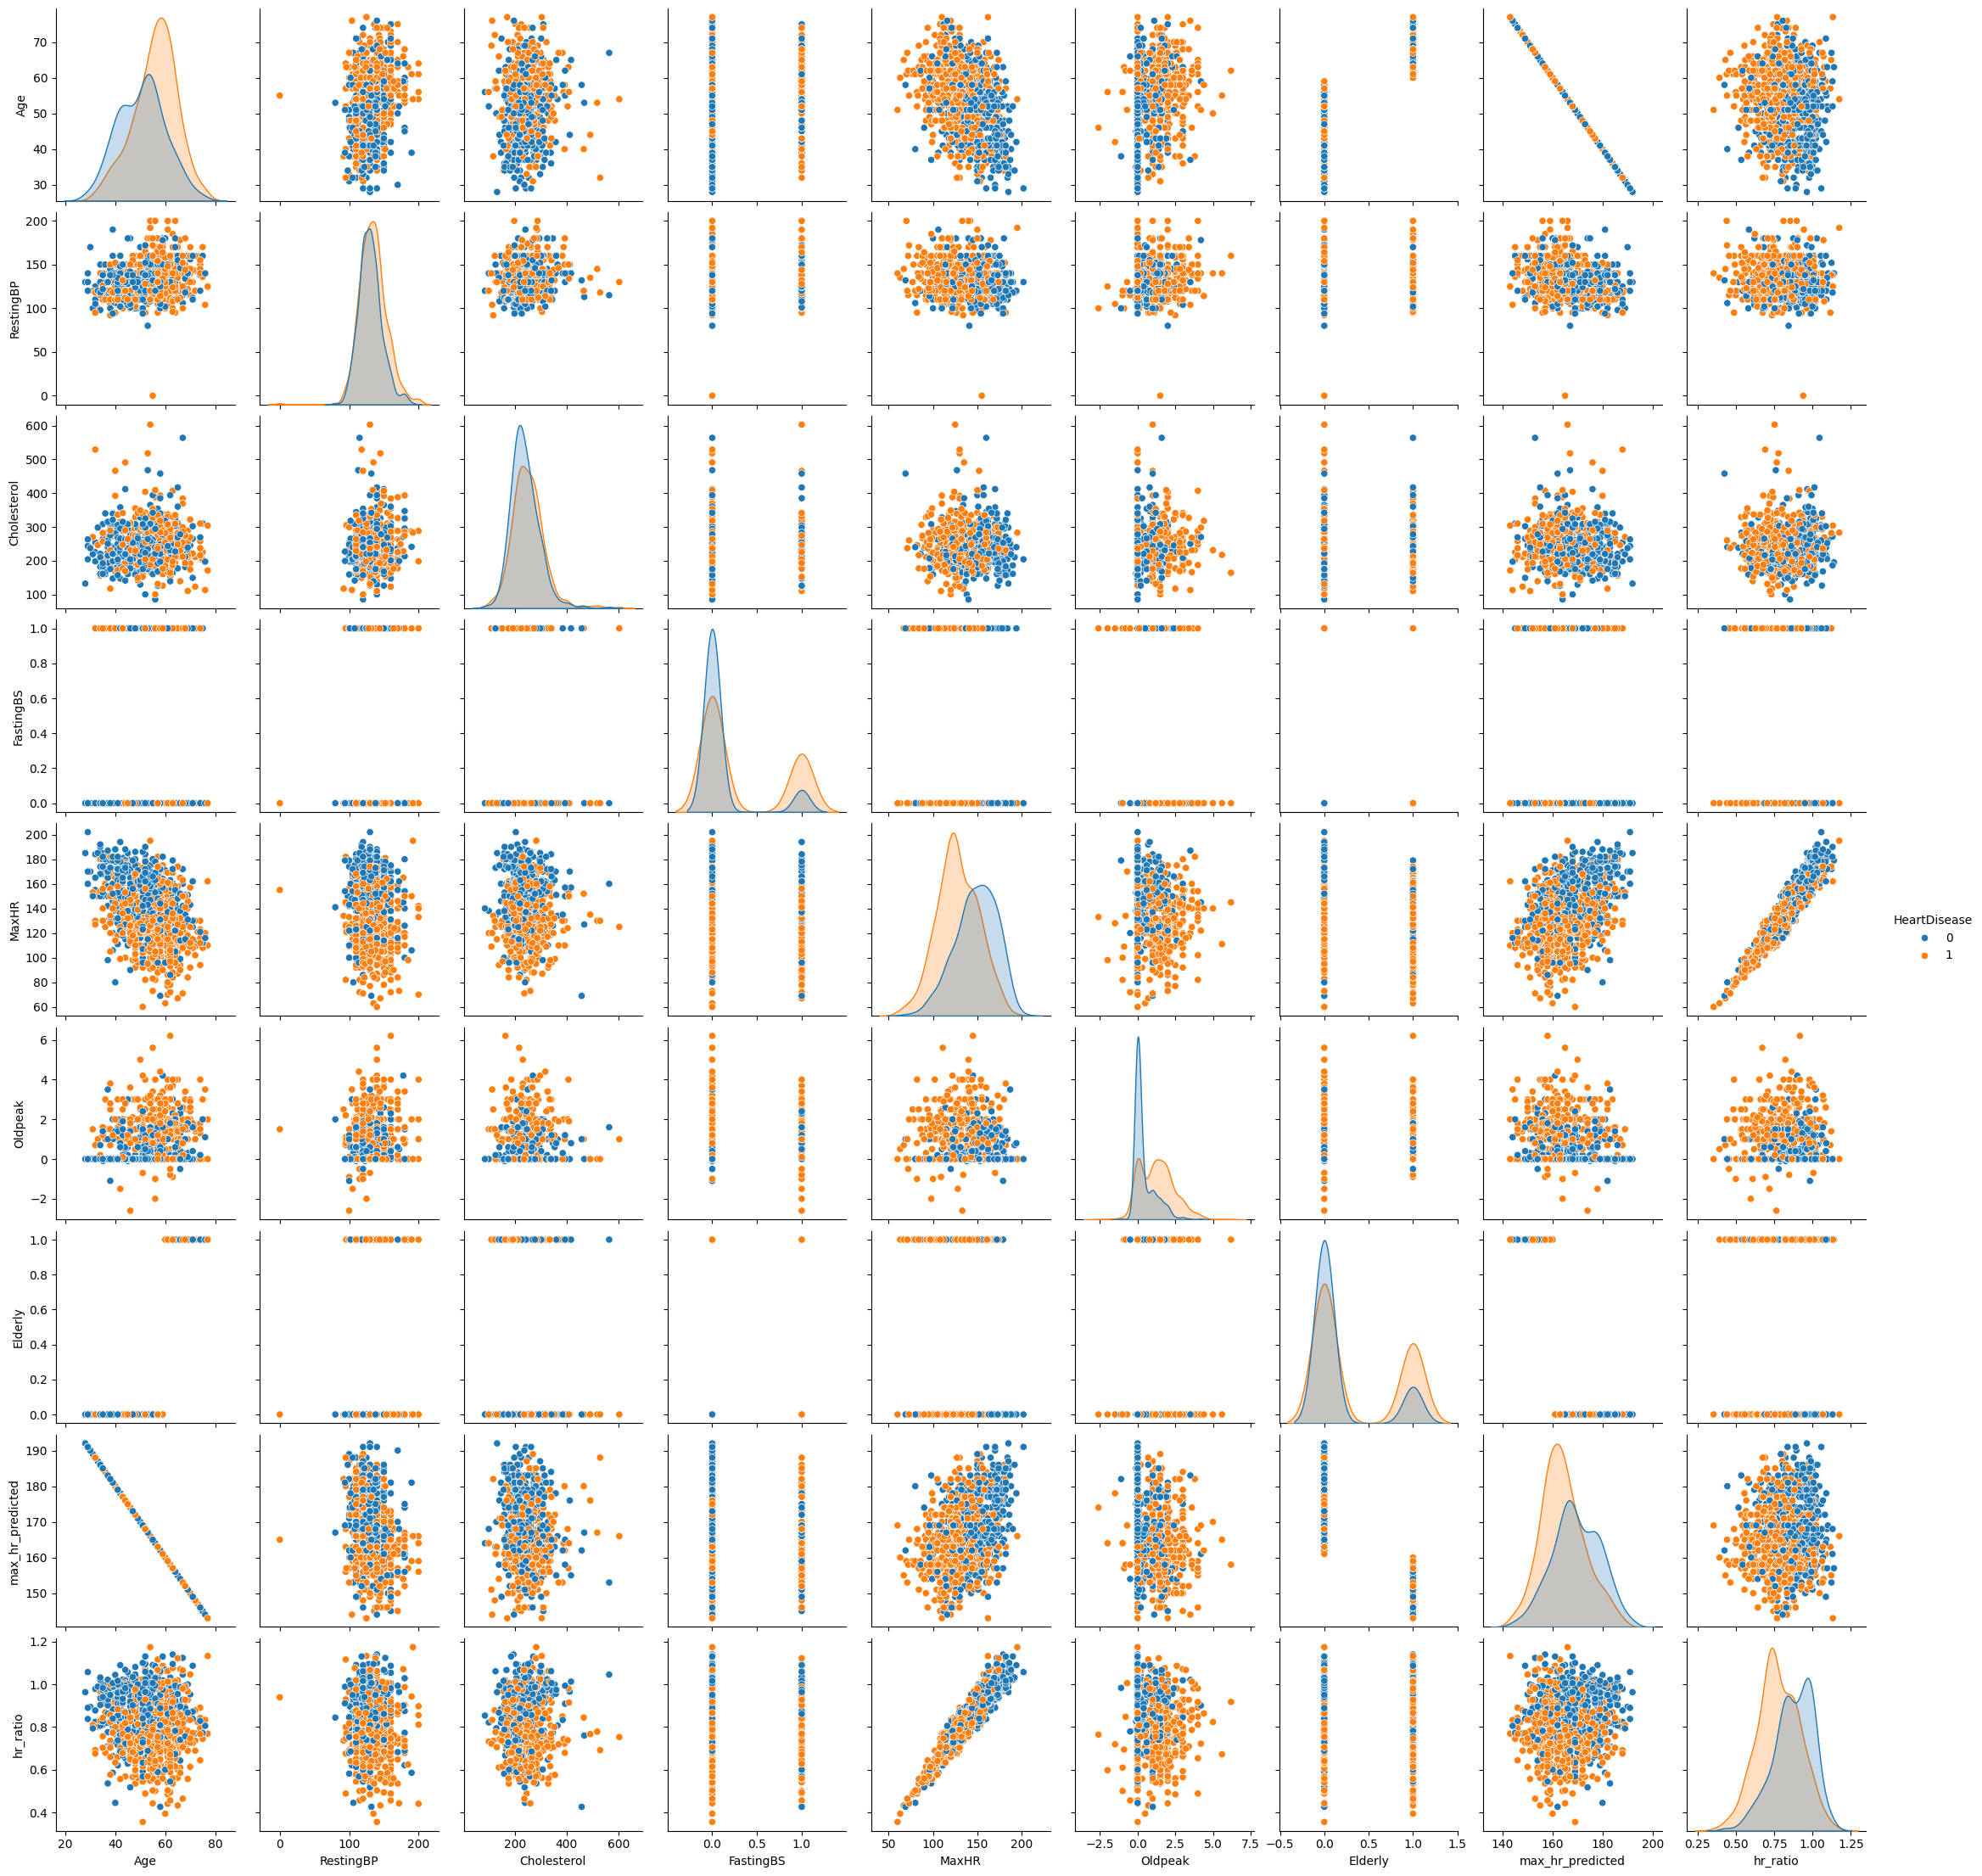

In [360]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="HeartDisease")
plt.show()

### General analysis

In [297]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [298]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [299]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [300]:
df.loc[df["HeartDisease"] == 1]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
11,58,M,ATA,136,164,0,ST,99,Y,2.0,Flat,1
13,49,M,ASY,140,234,0,Normal,140,Y,1.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1


In [301]:
df.loc[df["HeartDisease"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
903,56,M,ATA,130,221,0,LVH,163,N,0.0,Up,0
904,56,M,ATA,120,240,0,Normal,169,N,0.0,Down,0
906,55,F,ATA,132,342,0,Normal,166,N,1.2,Up,0
910,41,M,ATA,120,157,0,Normal,182,N,0.0,Up,0


Out of a total of 918 patients, 410 do not have hart disease, while 508 do.

### Laboratorial variables

In [302]:
lab_columns = ["Cholesterol", "FastingBS"]

In [303]:
df[lab_columns].corr()

,Cholesterol,FastingBS
Cholesterol,1.000000,-0.260974
FastingBS,-0.260974,1.000000


There is a **negative** correlation between cholesterol and fasting blood sugar, suggesting an inverse relationship: when one variable rises, the other tends to fall.

Statistics for patients with high cholesterol and 

In [304]:
results = []
for col in lab_columns:

    group = df.groupby(col)["HeartDisease"]

    means = group.mean()
    medians = group.median()
    counting = group.count()

    mean_without = means.get(0)
    median_without = medians.get(0)
    count_without = counting.get(0)

    mean_with = means.get(1)
    median_with = medians.get(1)
    count_with = counting.get(1)

    results.append({
        "Condition": col,
        "Mean without heart disease": mean_without,
        "Median without heart disease": median_without,
        "Patients without heart disease": count_without,
        "Mean with heart disease": mean_with,
        "Median with heart disease": median_with,
        "Patients with heart disease": count_with

    }
    )

    conditions_table = pd.DataFrame(results)

conditions_table

,Condition,Mean without heart disease,Median without heart disease,Patients without heart disease,Mean with heart disease,Median with heart disease,Patients with heart disease
0,Cholesterol,0.883721,1.0,172,NaN,NaN,NaN
1,FastingBS,0.480114,0.0,704,0.794393,1.0,214.0


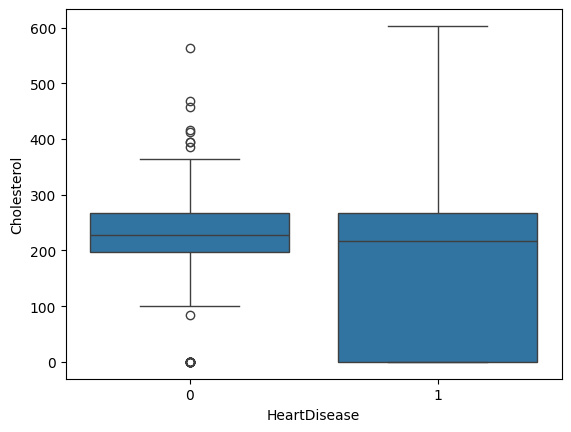

In [305]:
import seaborn as sns
sns.boxplot(x = "HeartDisease", y = "Cholesterol", data=df);

In [306]:
(df["Cholesterol"] == 0).sum()

np.int64(172)

There are many zero values for Cholesterol, which can indicate an error or missing data. So it's going to be replaced by "NaN".

#### Treating the 0 values in for Cholesterol

In [307]:
import numpy as np
df.loc[df["Cholesterol"] == 0, "Cholesterol"] = np.nan

##### Checking the boxplot again and analysing

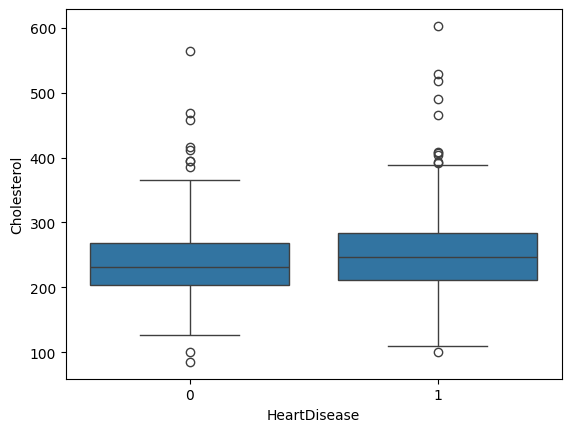

In [308]:
sns.boxplot(x="HeartDisease", y="Cholesterol", data=df);

In [309]:
def calculate_outliers_by_group(df, column, target):
    grouped = df.groupby(target)[column]

    Q1 = grouped.quantile(.25)
    Q3 = grouped.quantile(.75)
    IQR = Q3 - Q1

    return pd.DataFrame({
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Limit": Q1 - 1.5 * IQR,
        "Upper Limit": Q3 + 1.5 * IQR
    })

In [310]:
calculate_outliers_by_group(df, "Cholesterol", "HeartDisease")  

,Q1,Q3,IQR,Lower Limit,Upper Limit
HeartDisease,,,,,
0,203.0,269.00,66.00,104.000,368.000
1,212.0,283.25,71.25,105.125,390.125


##### Correlation between Cholesterol and HeartDisease

In [311]:
cholesterol_heart_corr = ["Cholesterol", "HeartDisease"]

df[cholesterol_heart_corr].corr()

,Cholesterol,HeartDisease
Cholesterol,1.000000,0.103866
HeartDisease,0.103866,1.000000


Altough there is a slight increase in choleterol levels among patients with heart disease, the distributions largely overlap. This suggeests that cholesterol alone may not be a strong discriminative feature for identifying heart disease in this dataset.

#### Analysing FastingBS

In [312]:
fastingbs_heart_corr = ["FastingBS", "HeartDisease"]
df[fastingbs_heart_corr].corr()

,FastingBS,HeartDisease
FastingBS,1.000000,0.267291
HeartDisease,0.267291,1.000000


In [313]:
df.loc[df["FastingBS"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
912,57,F,ASY,140,241.0,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264.0,0,Normal,132,N,1.2,Flat,1
915,57,M,ASY,130,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236.0,0,LVH,174,N,0.0,Flat,1


In [314]:
df.loc[df["FastingBS"] == 1]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
36,65,M,ASY,140,306.0,1,Normal,87,Y,1.5,Flat,1
38,48,F,ATA,120,177.0,1,ST,148,N,0.0,Up,0
52,45,M,ATA,140,224.0,1,Normal,122,N,0.0,Up,0
84,56,M,ASY,150,213.0,1,Normal,125,Y,1.0,Flat,1
86,65,M,ASY,170,263.0,1,Normal,112,Y,2.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
887,43,M,ASY,132,247.0,1,LVH,143,Y,0.1,Flat,1
888,52,M,ASY,128,204.0,1,Normal,156,Y,1.0,Flat,1
901,58,F,ASY,170,225.0,1,LVH,146,Y,2.8,Flat,1
911,59,M,ASY,164,176.0,1,LVH,90,N,1.0,Flat,1


Almost 77% of the patients have FastingBS greater than 120.

In [315]:
ct = pd.crosstab(df["FastingBS"], df["HeartDisease"], normalize="index")
ct

HeartDisease,0,1
FastingBS,,
0,0.519886,0.480114
1,0.205607,0.794393


In [316]:
odds_true = ct.loc[1, 1] / ct.loc[1, 0]
odds_false = ct.loc[0, 1] / ct.loc[0, 0]

odds_ratio = odds_true / odds_false

print(odds_ratio)

4.183700914470146


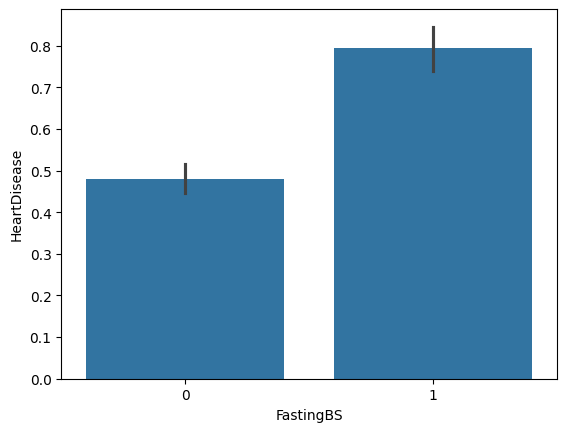

In [317]:
sns.barplot(x="FastingBS", y="HeartDisease", data=df);

79% of the patients with fasting blood sugar greater than 120 also have heart disease.

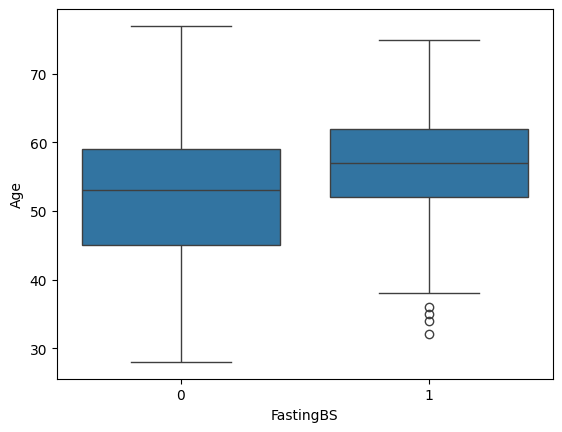

In [318]:
sns.boxplot(x="FastingBS", y="Age", data=df);

In [319]:
fastinbs_age_corr = ["FastingBS", "HeartDisease"]
df[fastinbs_age_corr].corr()

,FastingBS,HeartDisease
FastingBS,1.000000,0.267291
HeartDisease,0.267291,1.000000


The proportion of heart disease is substantially higher among patients with elevated fasting blood sugar (~79%) compared to those withou (~48%). This results in a high odds ration (~4.18), indicating a strong association. However, this finding should be interpreted with caution due to the high prevalence of elevated fasting blood sugar in teh dataset, which may reflect a biased or high-risk population.

When comparing fasting blood sugar with patient age, the boxplot suggests that older patients tend to have higher fasting blood sugar levels. This observation is supported by a positive, although weak, correlation in the correlation matrix, indicating a slight association between age and fasting blood sugar.

### Demographic variables

In [320]:
demographic = ["Age", "Sex"]

#### Age analysis

In [321]:
df["Elderly"] = df["Age"] >= 60
elderly_heart_disease = df.loc[(df["Elderly"]) & (df["HeartDisease"])]

elderly_heart_disease

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Elderly
18,60,M,ASY,100,248.0,0,Normal,125,N,1.0,Flat,1,True
36,65,M,ASY,140,306.0,1,Normal,87,Y,1.5,Flat,1,True
82,63,M,ASY,150,223.0,0,Normal,115,N,0.0,Flat,1,True
85,66,M,ASY,140,139.0,0,Normal,94,Y,1.0,Flat,1,True
86,65,M,ASY,170,263.0,1,Normal,112,Y,2.0,Flat,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,61,M,ASY,148,203.0,0,Normal,161,N,0.0,Up,1,True
905,67,M,NAP,152,212.0,0,LVH,150,N,0.8,Flat,1,True
908,63,M,ASY,140,187.0,0,LVH,144,Y,4.0,Up,1,True
909,63,F,ASY,124,197.0,0,Normal,136,Y,0.0,Flat,1,True


In [322]:
ct = pd.crosstab(df["Elderly"], df["HeartDisease"], normalize="index")
ct

HeartDisease,0,1
Elderly,,
False,0.514286,0.485714
True,0.268775,0.731225


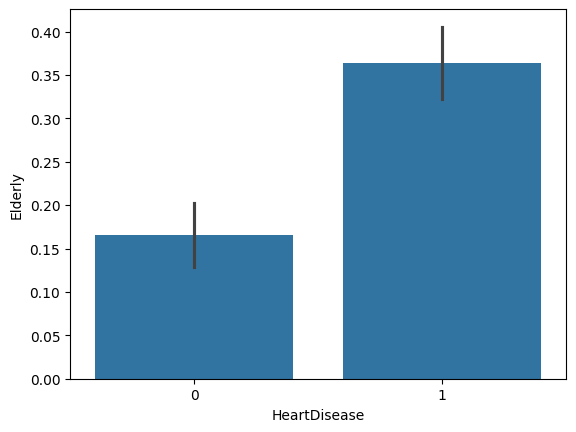

In [323]:
sns.barplot(x = "HeartDisease", y = "Elderly", data = df);

In [324]:
df[["Elderly", "HeartDisease"]].corr()

,Elderly,HeartDisease
Elderly,1.000000,0.220657
HeartDisease,0.220657,1.000000


The crosstab shows that among elderly patients, 73.12% have heart disease, compared to 48.57% among non-elderly, indicating a higher risk in the elderly group . Meanwhile, the barlot shows that among patients with heart disease, approximatedely ~35% are elderly, meaning most patients with heart disease are not elderly. 

About the correlation, elderly have a weak positive correlation with heart disease, though the relationship appears weak.

#### Sex analysis

In [325]:
ct_sex = pd.crosstab(df["Sex"], df["HeartDisease"], normalize=True)
ct_sex

HeartDisease,0,1
Sex,,
F,0.155773,0.054466
M,0.290850,0.498911


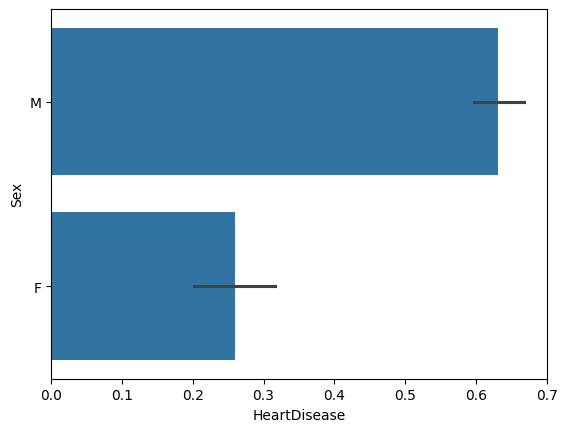

In [326]:
sns.barplot(df, x="HeartDisease", y="Sex");

The crosstab indicates a higher risk of heart disease among male patients (49.89%), compared to female patients (29.08%), suggesting that males are at greater risk. Additionally, the bar plot shows that approximately 60% of patients with heart disease are male, reinforcing the observed gender disparity, altough this proportion may also reflect gender distribution in the dataset.

## DELETAR

💡 Resumo direto

Você já sabe ler os dados.
Agora precisa treinar:

Estrutura (fato → interpretação → nuance)
Precisão na linguagem
Evitar confundir métricas

### Complementary exams

In [327]:
complementary_exams = ["RestingECG", "MaxHR", "ExerciseAngina", "Oldpeak", "ST_Slope"]
df[complementary_exams]

,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,Normal,172,N,0.0,Up
1,Normal,156,N,1.0,Flat
2,ST,98,N,0.0,Up
3,Normal,108,Y,1.5,Flat
4,Normal,122,N,0.0,Up
...,...,...,...,...,...
913,Normal,132,N,1.2,Flat
914,Normal,141,N,3.4,Flat
915,Normal,115,Y,1.2,Flat
916,LVH,174,N,0.0,Flat


In [328]:
pd.crosstab(df["RestingECG"], df["HeartDisease"], normalize="index")

HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


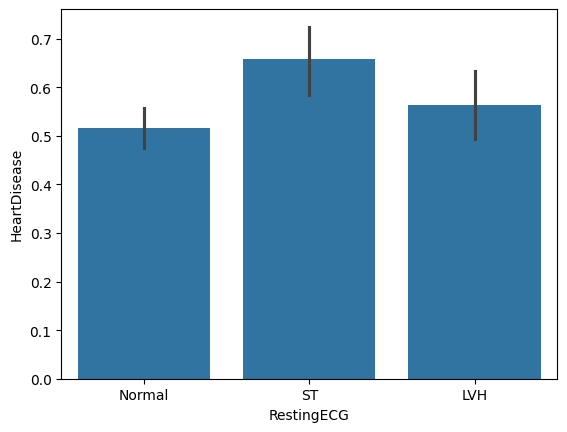

In [329]:
sns.barplot(x="RestingECG", y="HeartDisease", data=df);

Patients with ST abnormalities in resting ECG show the highest probability of heart disease (approximately 70%), followed by those with LVH. Patients with normal ECG results still present a considerable probability of heart disease, around 50%. This indicates that a normal resting ECG does not necessarily rule out the presence of heart disease.

In [330]:
df["max_hr_predicted"] = 220 - df["Age"]
df["hr_ratio"] = df["MaxHR"] / df["max_hr_predicted"]

In [331]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Elderly,max_hr_predicted,hr_ratio
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0,False,180,0.955556
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1,False,171,0.912281
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0,False,183,0.535519
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1,False,172,0.627907
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0,False,166,0.734940


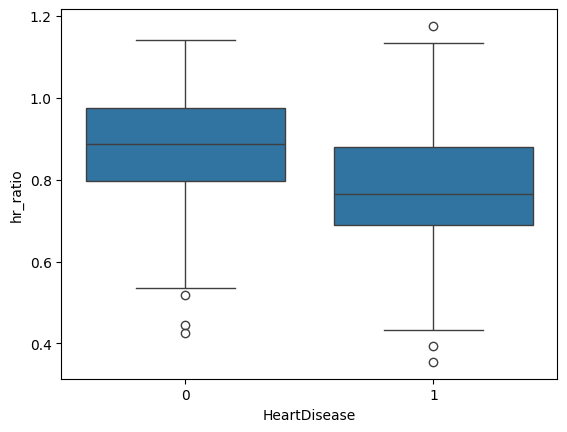

In [332]:
sns.boxplot(x="HeartDisease", y="hr_ratio", data=df);

Patients with heart disease tend to have lower heart rate ratios compared to those without the condition, indicating that they achieve a smaller proportion of their expected maximum heart rate. The distributions show some overlap, but the median is clearly lower in the heart disease group. Outliers are present in both groups, suggesting variability in individual responses.

#### Exercise Angina

In [333]:
df["ExerciseAngina"]

0      N
1      N
2      N
3      Y
4      N
      ..
913    N
914    N
915    Y
916    N
917    N
Name: ExerciseAngina, Length: 918, dtype: str

In [334]:
pd.crosstab(df["ExerciseAngina"], df["HeartDisease"], normalize="index")

HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


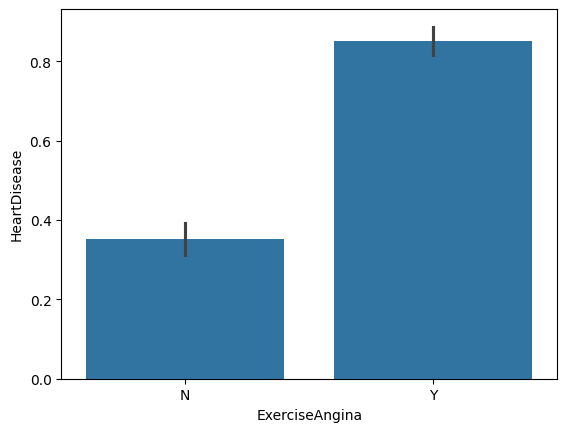

In [335]:
sns.barplot(x="ExerciseAngina", y="HeartDisease", data=df);

#### Oldpeak

In [336]:
df["Oldpeak"]

0      0.0
1      1.0
2      0.0
3      1.5
4      0.0
      ... 
913    1.2
914    3.4
915    1.2
916    0.0
917    0.0
Name: Oldpeak, Length: 918, dtype: float64

In [337]:
corr = df["Oldpeak"].corr(df["HeartDisease"])
corr

np.float64(0.40395072206288685)

In [338]:
from math import inf

bins = [-float(inf), 1.0, 2.0, float(inf)]
labels = ["low", "moderated", "high"]
df["oldpeak_risk"] = pd.cut(df["Oldpeak"], bins=bins, labels=labels)

It's created a new column with categories for oldpeak, indicating the risk each value represents according to the range.

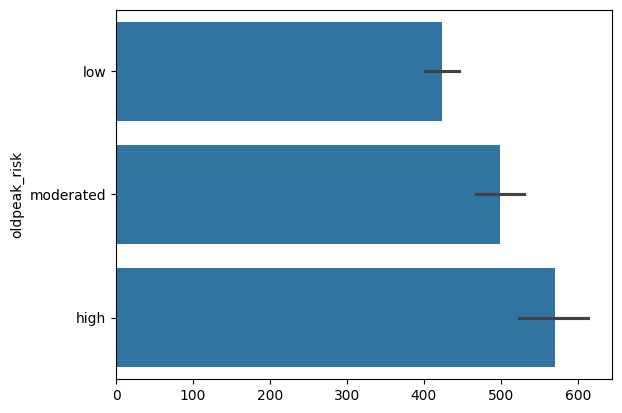

In [339]:
sns.barplot(df["oldpeak_risk"]);

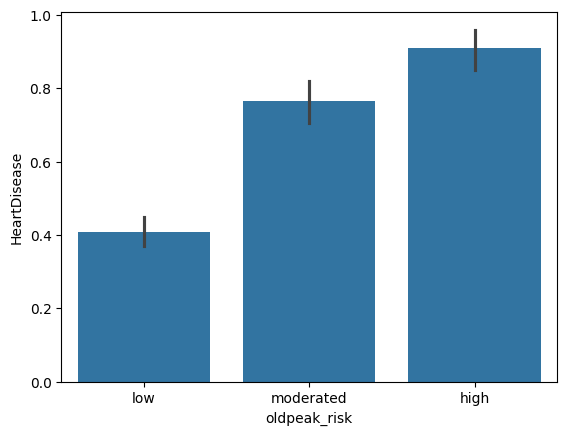

In [340]:
sns.barplot(x="oldpeak_risk", y="HeartDisease", data=df);

### ST_Slope

In [341]:
df["ST_Slope"]

0        Up
1      Flat
2        Up
3      Flat
4        Up
       ... 
913    Flat
914    Flat
915    Flat
916    Flat
917      Up
Name: ST_Slope, Length: 918, dtype: str

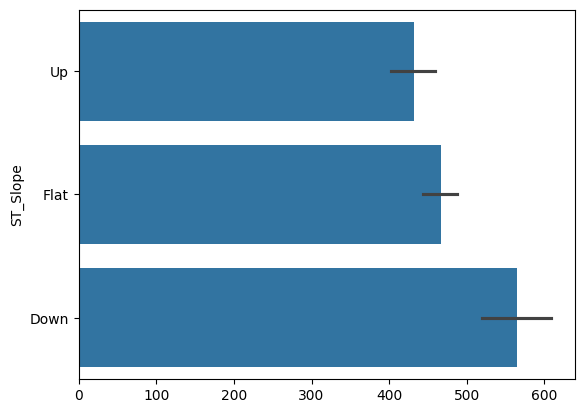

In [342]:
sns.barplot(df["ST_Slope"]);

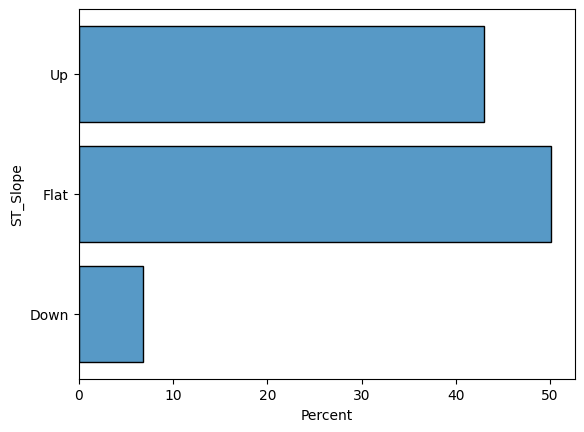

In [343]:
sns.histplot(data=df, y="ST_Slope", stat="percent", shrink=0.8);

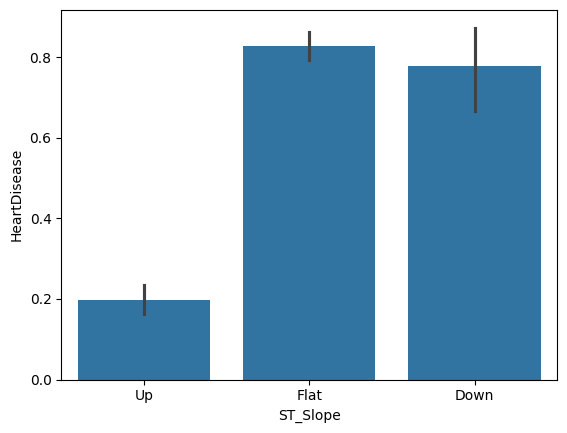

In [344]:
sns.barplot(x="ST_Slope", y="HeartDisease", data=df);

In [345]:
key_exams = ["oldpeak_risk", "ST_Slope"]

df[key_exams]

,oldpeak_risk,ST_Slope
0,low,Up
1,low,Flat
2,low,Up
3,moderated,Flat
4,low,Up
...,...,...
913,moderated,Flat
914,high,Flat
915,moderated,Flat
916,low,Flat


In [351]:
pd.crosstab([df["oldpeak_risk"], df["ST_Slope"]], df["HeartDisease"], normalize="index")

HeartDisease                  0         1
oldpeak_risk ST_Slope                    
low          Down      0.454545  0.545455
             Flat      0.200873  0.799127
             Up        0.855072  0.144928
moderated    Down      0.200000  0.800000
             Flat      0.172619  0.827381
             Up        0.525000  0.475000
high         Down      0.148148  0.851852
             Flat      0.063492  0.936508
             Up        0.100000  0.900000

In [353]:
pd.crosstab(df["oldpeak_risk"], df["HeartDisease"], normalize="index")

HeartDisease,0,1
oldpeak_risk,,
low,0.591453,0.408547
moderated,0.236052,0.763948
high,0.090000,0.910000


In [355]:
pd.crosstab(df["ST_Slope"], df["HeartDisease"], normalize="index")

HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


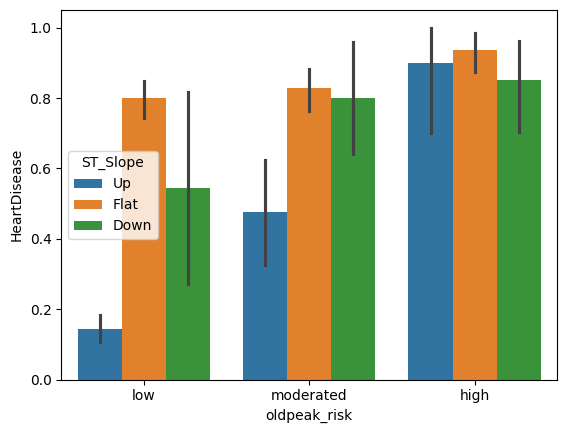

In [359]:
sns.barplot(x="oldpeak_risk", y="HeartDisease", hue="ST_Slope", data=df, order=["low", "moderated", "high"], hue_order=["Up", "Flat", "Down"]);

Bold ```oldpeak_risk``` and ```ST_Slope``` show strong individual associations with heart disease. However, their combined analysis reveals an interaction effect: while ```oldpeak_risk``` largely determines the olverall risk level, ```ST_Slope``` significantly modifies the probability of heart disease, particularly in low and moderated risk groups. In high-risk cases, the probability of heart disease remains hgih regardless of the ```ST_Slope```, suggesting that ```oldpeak_risk```dominates in these scenarios.

### Exporting the treated data

In [364]:
df_treated = df.to_csv("../data/treated/heart_treated.csv")